In [2]:
!nvidia-smi


'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


### Import libraries: 

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split as tts
from sklearn.ensemble import RandomForestRegressor



print("done!")

done!


### Import Data :


In [4]:
df = pd.read_csv("Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.shape

(300153, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [7]:
# Naming the unamed index column
df = df.rename(columns = {df.columns[0]: "id"})

In [8]:
# displaying as lists the unique elements of each column

airlines = df["airline"].unique().tolist()
flights = df["flight"].unique().tolist()
source_cities = df["source_city"].unique().tolist()
departure_times = df["departure_time"].unique().tolist()
stops = df["stops"].unique().tolist()
arrival_times = df["arrival_time"].unique().tolist()
destination_cities = df["destination_city"].unique().tolist()
classes = df["class"].unique().tolist()

print("Airlines:", airlines)
print("Number of unique flights:", len(flights))
print("Source Cities:", source_cities)
print("Departure Times:", departure_times)
print("Stops:", stops)
print("Arrival Times:", arrival_times)
print("Destination Cities:", destination_cities)
print("Classes:", classes)

Airlines: ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Number of unique flights: 1561
Source Cities: ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Departure Times: ['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Stops: ['zero', 'one', 'two_or_more']
Arrival Times: ['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
Destination Cities: ['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Classes: ['Economy', 'Business']


In [9]:
# Mapping the stops column to numerical representative values
if df['stops'].dtype == 'object': 
    df['stops'] =df['stops'].map({'zero':0, 'one' : 1, 'two_or_more' :2})
    print("results : ",df['stops'].unique().tolist())
else :
    print("stops column already mapped :",df['stops'].unique().tolist())

stops column already mapped : ['zero', 'one', 'two_or_more']


### Classify the discrete, continuous, and categorical variables

In [10]:
discrete_variables = []
continuous_variables = []
categorical_variables = []


for var in df.columns :
    if df[var].dtype == 'str' :
        categorical_variables.append(var)

    elif df[var].dtype == 'int64' or (df[var].dtype == 'float64' and (df[var].dropna() % 1 == 0).all()) :
        
        if len(df[var].unique()) > 100 :
            continuous_variables.append(var)
        else :
            discrete_variables.append(var)
            
    elif (df[var].dtype == 'float64' and (df[var].dropna() % 1 != 0).any()):
        continuous_variables.append(var)
        
    else:
        print(var, "is unknown")

print("Discrete:", discrete_variables)
print("Continuous:", continuous_variables)
print("Categorical:", categorical_variables)

Discrete: ['days_left']
Continuous: ['id', 'duration', 'price']
Categorical: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


### ML Pipline

### Encoding ordinal and nominal columns :

In [11]:
df["departure_time"].unique().tolist()

['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']

In [12]:
df["arrival_time"].unique().tolist()

['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']

### Ordinal encoding using Mapping 

In [13]:
time_mapping = {
    'Early_Morning': 1,
    'Morning': 2,
    'Afternoon': 3,
    'Evening': 4,
    'Night': 5,
    'Late_Night': 6
}
#mapping :
for col in ['arrival_time', 'departure_time' ]:
    if col in df.columns:
        if df[col].dtype == 'str': 
            df[col + '_mapped'] = df[col].map(time_mapping)
            print("results : ",df[col + '_mapped'].unique().tolist())
            df.drop(columns= col , inplace=True)
        else :
            print(f"{col} column already mapped : {df[col+'_mapped'].unique().tolist()}")     
    else :
        print(f"{col} column already mapped : {df[col+'_mapped'].unique().tolist()}")

results :  [5, 2, 1, 3, 4, 6]
results :  [4, 1, 2, 3, 5, 6]


### Nominal Encoding Using OneHotMapping 

In [14]:
# Drop the 'flight' column before nominal encoding:
# It has 1,561 unique values — too many for One-Hot Encoding (causes overfitting and memory issues).
# Its useful information is already captured by 'airline', 'source_city', and 'destination_city'.

df.drop(columns="flight", inplace=True)
print("done!")

done!


In [15]:
#columns = ['airline','flight', 'source_city', 'destination_city', "class"]




columns = df.select_dtypes( include ='str').columns.tolist()

for col in columns :
    if col in df.columns :
        if df[col].dtype == 'str':
            encoder = OneHotEncoder(sparse_output=False)
            encoded = encoder.fit_transform(df[[col]])
            df[encoder.get_feature_names_out([col])] = encoded 
            df.drop(columns=col, inplace = True)
        else :
            print("columns are already encoded")
    else :
        print("columns are already encoded and originals were droped")


In [16]:
df

,id,duration,days_left,price,arrival_time_mapped,departure_time_mapped,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,...,stops_two_or_more,stops_zero,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Business,class_Economy
0,0,2.17,1,5953,5,4,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,2.33,1,5953,2,1,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2.17,1,5956,1,1,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,3,2.25,1,5955,3,2,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,4,2.33,1,5955,2,2,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,10.08,49,69265,4,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300149,300149,10.42,49,77105,5,3,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300150,300150,13.83,49,79099,5,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300151,300151,10.00,49,81585,4,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### defining the parameters x, y :

In [17]:
x = df.drop(columns = 'price') #features
y = df['price'] #Target
print("done!")

done!


In [18]:
from sklearn.model_selection import train_test_split as tts
x_train,x_test, y_train, y_test = tts(x 
                                     ,y 
                                     , test_size = 0.2 
                                     , random_state = 42)
print("done!")

done!


In [19]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
y_pred = model.predict(x_test)
print("Predictions done!")

Predictions done!


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error):     {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R² Score:                        {r2*100:.4f}%")


MAE  (Mean Absolute Error):     943.20
RMSE (Root Mean Squared Error): 2479.05
R² Score:                        98.8078%


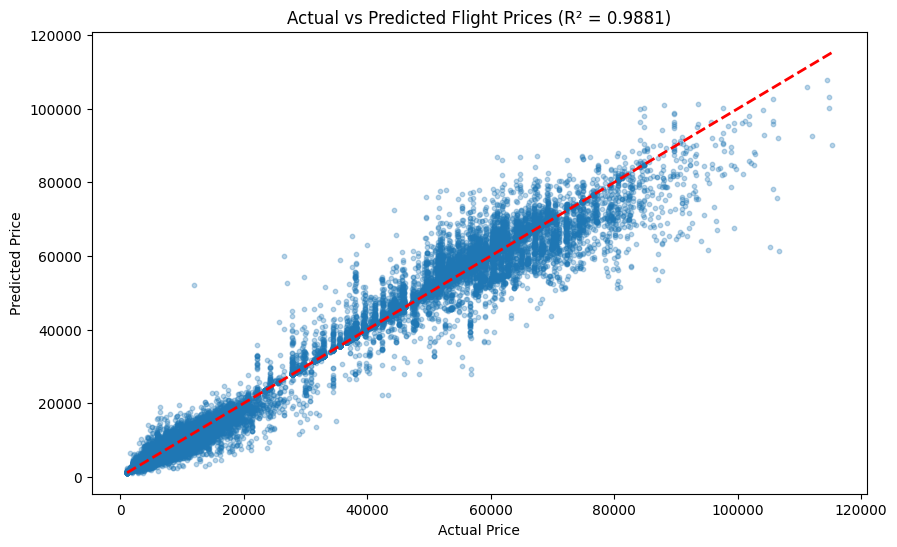

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices (R² = 0.9881)")
plt.show()